In [1]:
from diagnostics import * 

import torch
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [4]:
# Default parameters
J = 7
Q = 3
M = 128
sigma = 3.5
nt = 40000
n1 = 5000

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1]).to(device)

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800])
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 128])


In [7]:
# ------------------------------------------------------------------
# Experiment definitions
# ------------------------------------------------------------------
experiments = {
    'GGk - No interactions': {
        'label': 'GGk - No interactions ψ',
        'suffix': f'_nt{nt}_n1_{n1}_GaussianK_lam_5e-07_Q=3only',
        'terms': [
            'L_2_lowpass',
            'Scattering_Fourth_Order_Mod2_Real_Q1',
            'Scalar_psi_GenGamma',
            'Scalar_morlet_GenGamma',
        ],
    },
}

for key, exp in experiments.items():
    # Check if it's the last experiment and adjust parameters
    #if key == 'GGG':
    #    current_M, current_J = 256, 7
    #else:
    current_M, current_J = M, J
    print(current_M, current_J)
        
    base_config = f'turbulence_synthesis_{current_M}_J_{current_J}_Q_{Q}_sigma_{sigma}'
    
    exp['config'] = base_config + exp['suffix']
    print(key, '->', exp['config'])

128 7
GGk - No interactions -> turbulence_synthesis_128_J_7_Q_3_sigma_3.5_nt40000_n1_5000_GaussianK_lam_5e-07_Q=3only


## Optionally coarse grain and compute diagnostics 

Loading GGk - No interactions ψ ...
All experiments loaded.
torch.Size([5000, 1, 128])
Marginal histograms


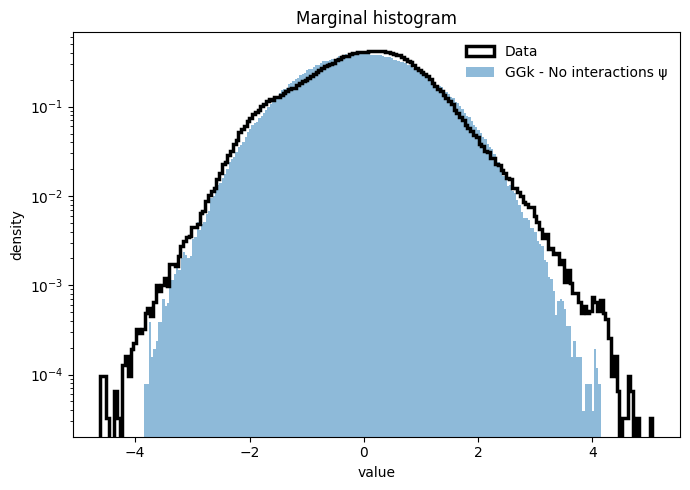

Per-band wavelet histograms  (one model at a time)


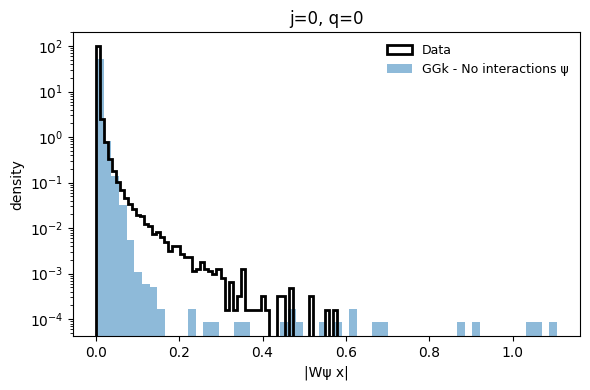

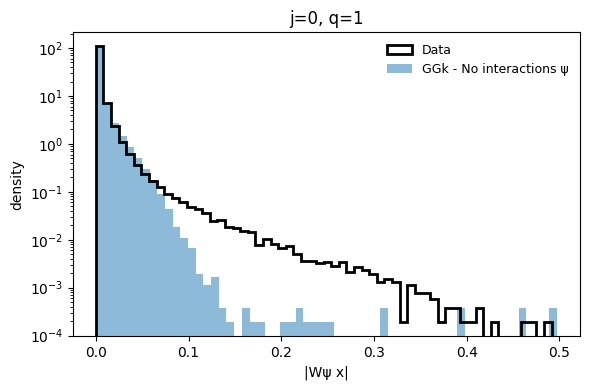

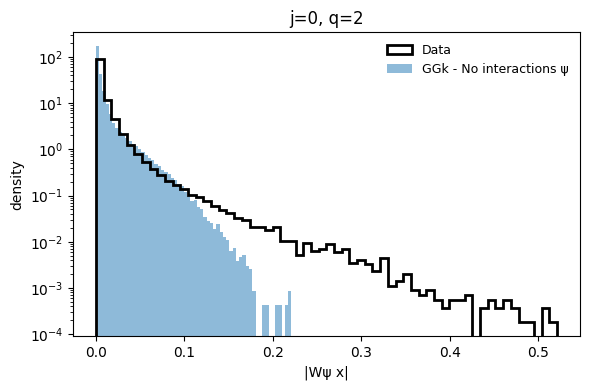

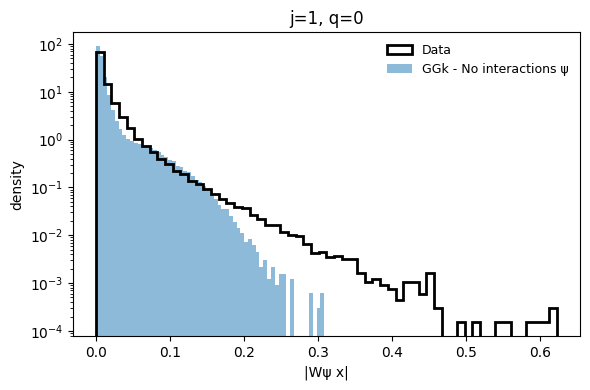

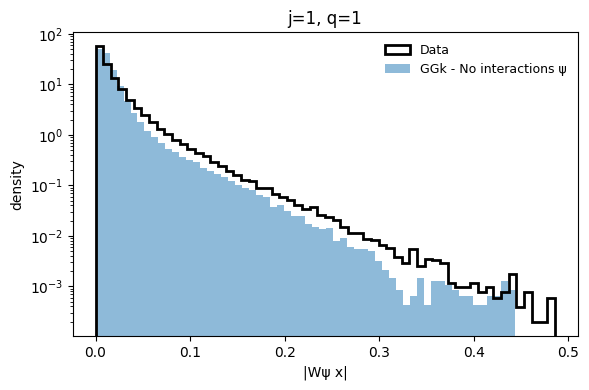

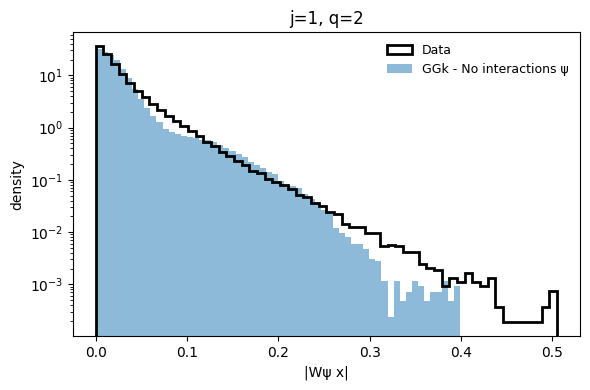

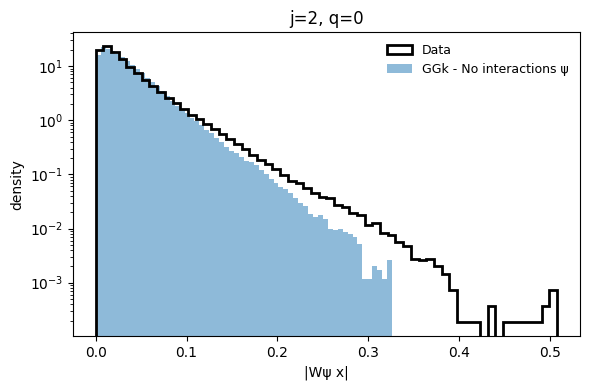

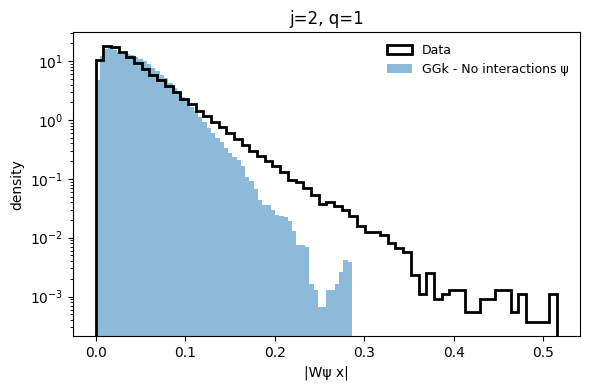

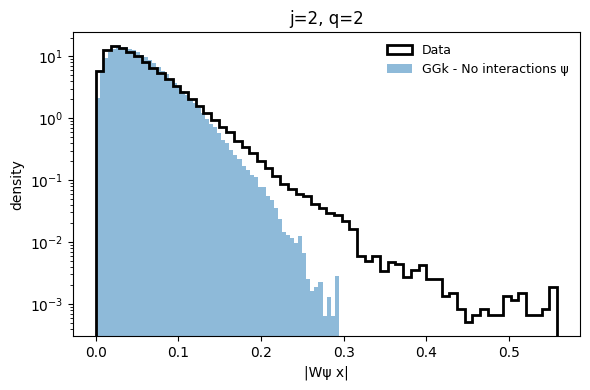

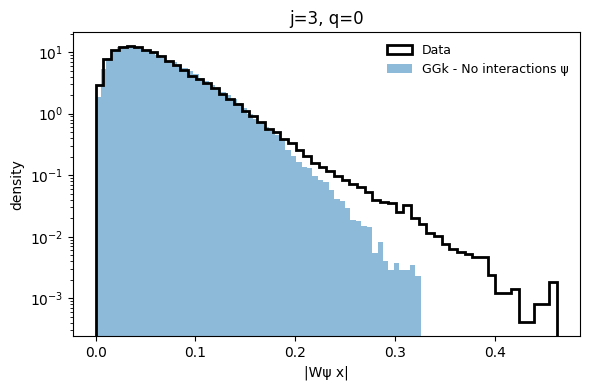

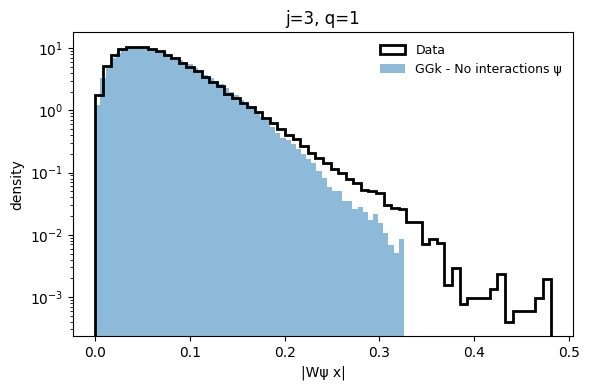

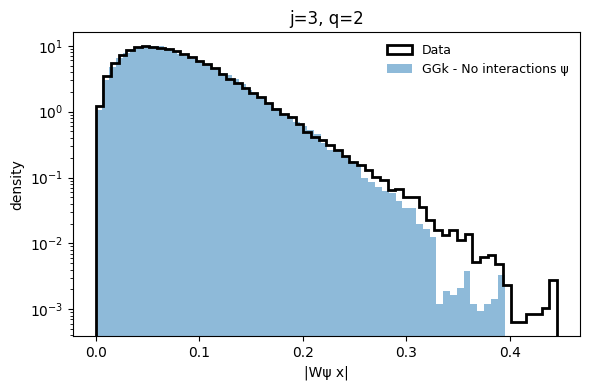

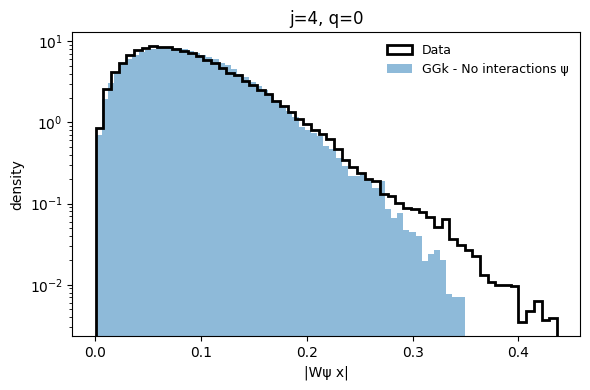

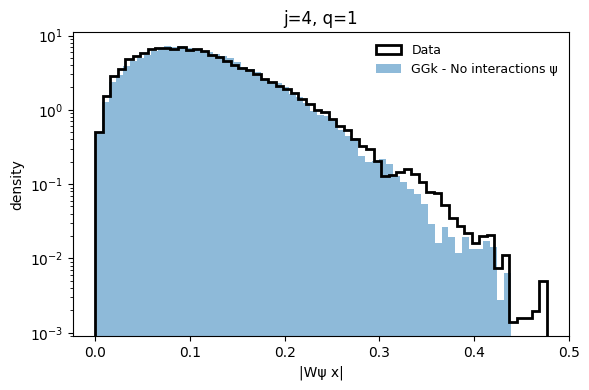

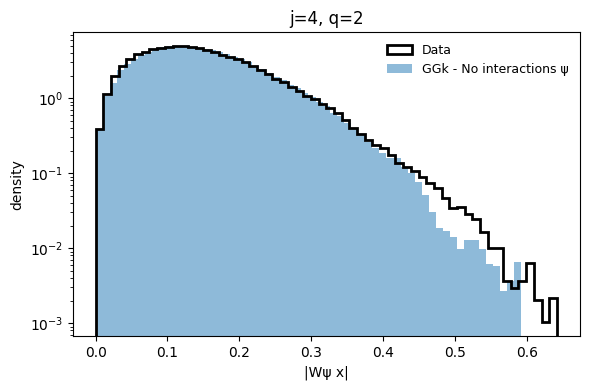

Visual comparison panels


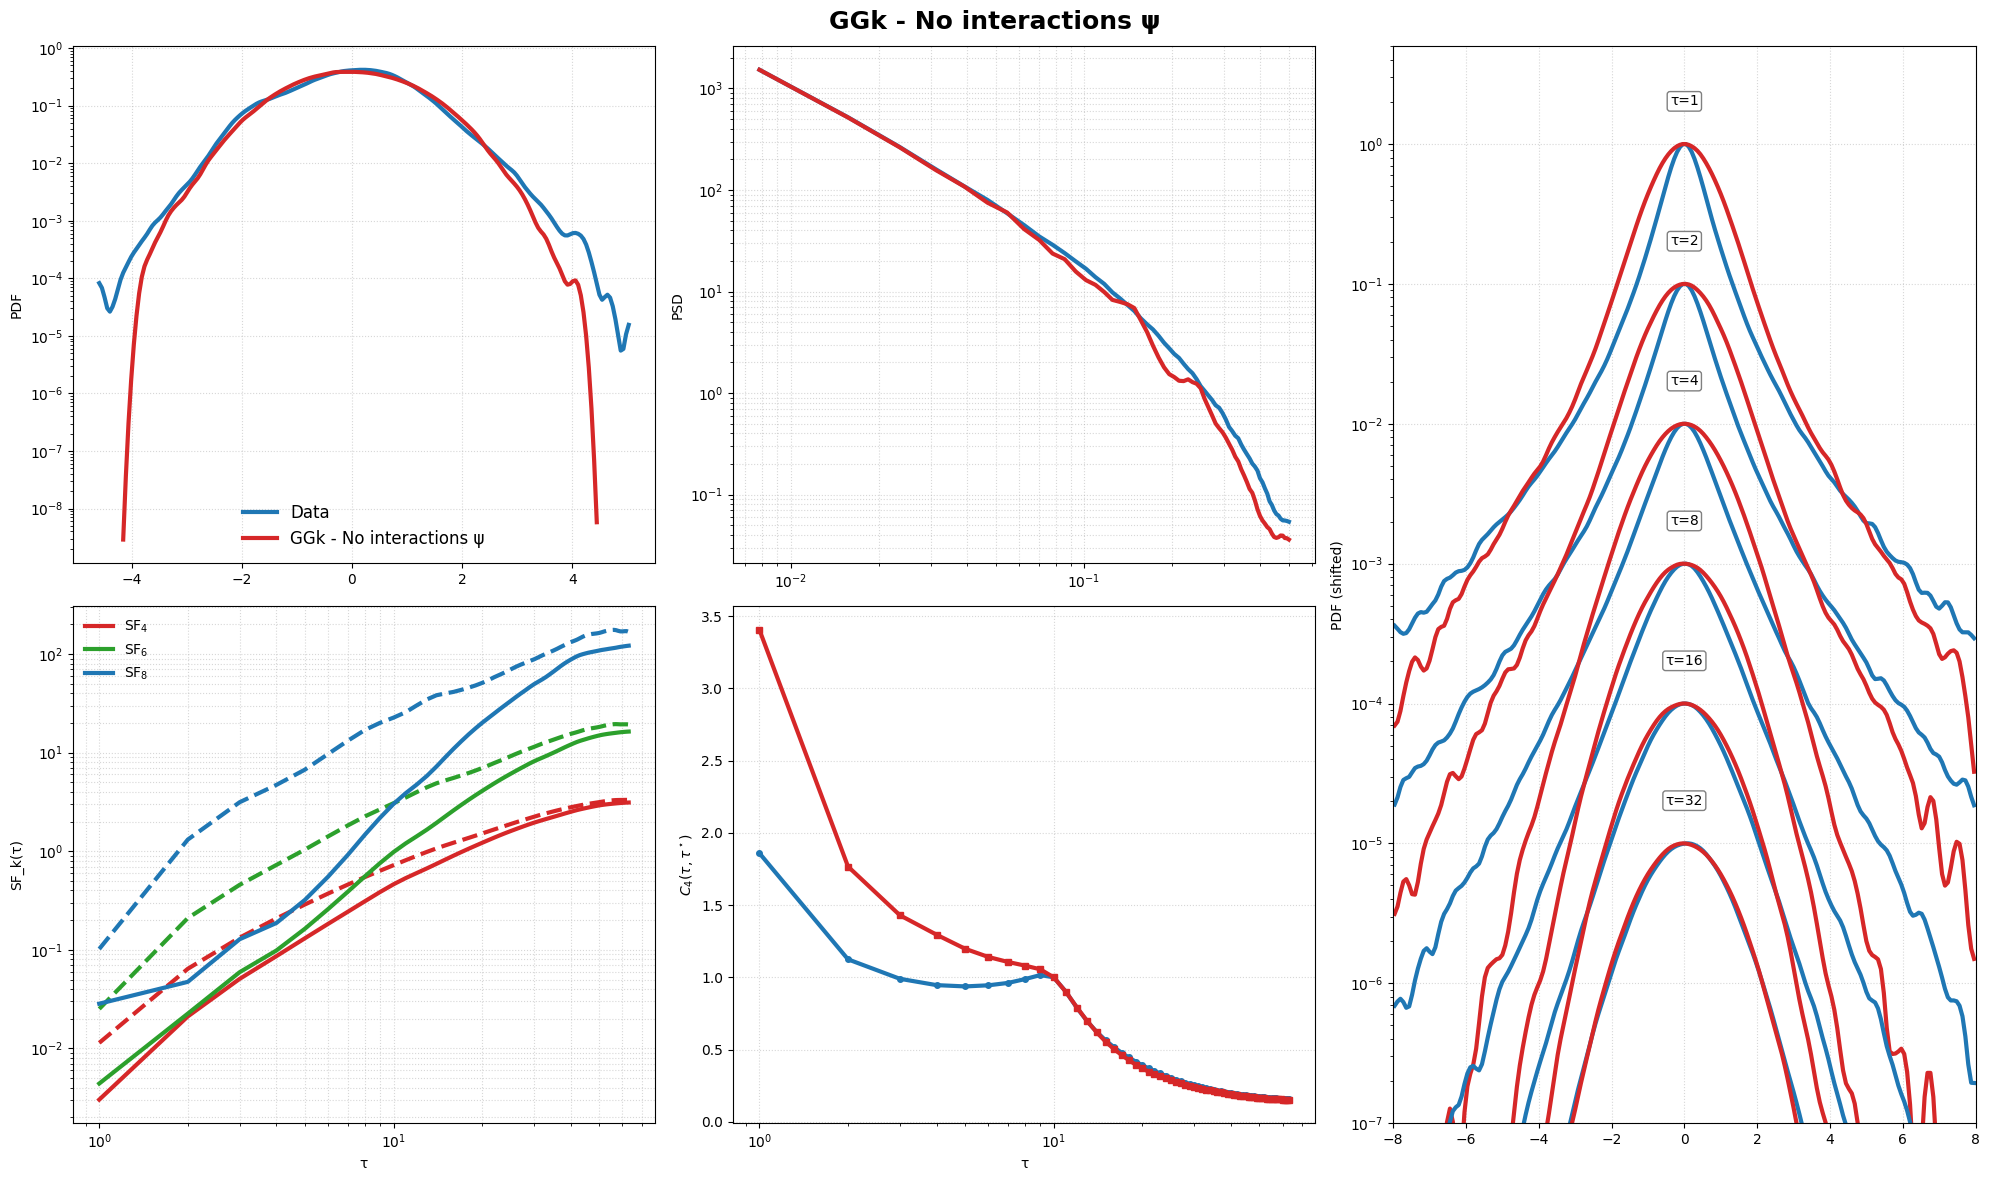

Scalar metrics
                         mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
GGk - No interactions ψ   259232.734375       0.007654          0.000188          0.052112           0.029799


,mean_rel_error,std_rel_error,spectrum_rel_mse,wasserstein_mean,structure_rel_mse
GGk - No interactions ψ,259232.734375,0.007654,0.000188,0.052112,0.029799


In [8]:
# 1. Load your experiments as you normally do
results = load_all_experiments(experiments, root, device)

# 2. Coarse-grain only the experiments that have M=256 (length 256)
for key, exp in experiments.items():
    xt = results[key]['xt']
    print(xt.shape) 
    
    # Check if the signal length matches your 256 experiment
    # Assuming the dimension to change is the last axis (e.g., shape [-1])
    # if xt.shape[-1] == 256:
    #     print(f"Coarse-graining '{key}' from {xt.shape} to match target length 128...")
        
    #     # Decompose once to drop the size from 256 to 128
    #     # (W.decompose usually returns (details, approximations) or vice versa; 
    #     # ensure index [1] represents the low-frequency/coarse approximation in your toolkit)
    #     xt_cg = W.decompose(xt)[1] 
        
    #     # Update the results dictionary with the downsampled signal
    #     results[key]['xt'] = xt_cg
        
    #     print(f"New shape for '{key}': {results[key]['xt'].shape}")

# 3. Now run your diagnostics safely—all signals in `results` are now length 128
df = run_diagnostics(x1, results, experiments)
df  # displays the metrics table in Jupyter

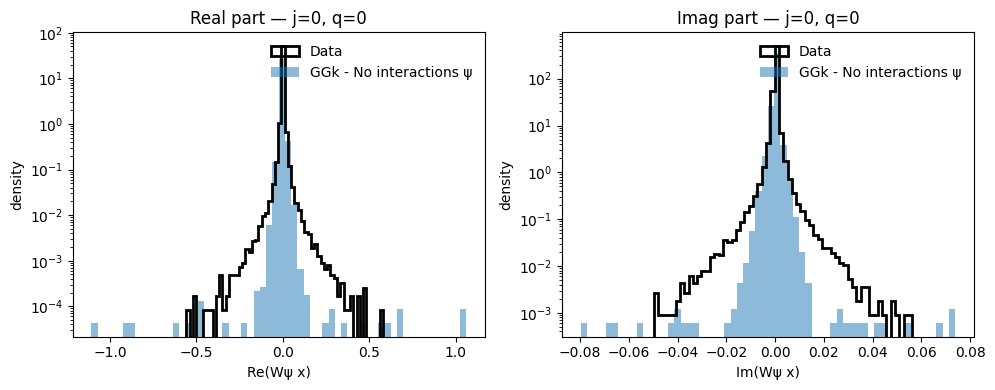

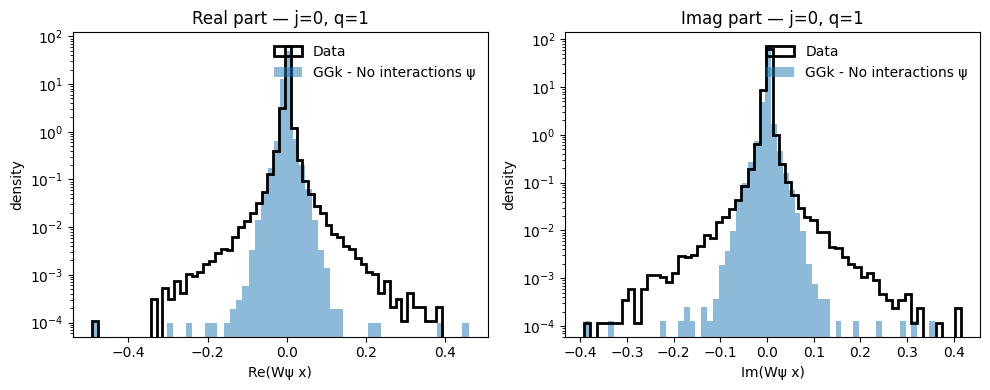

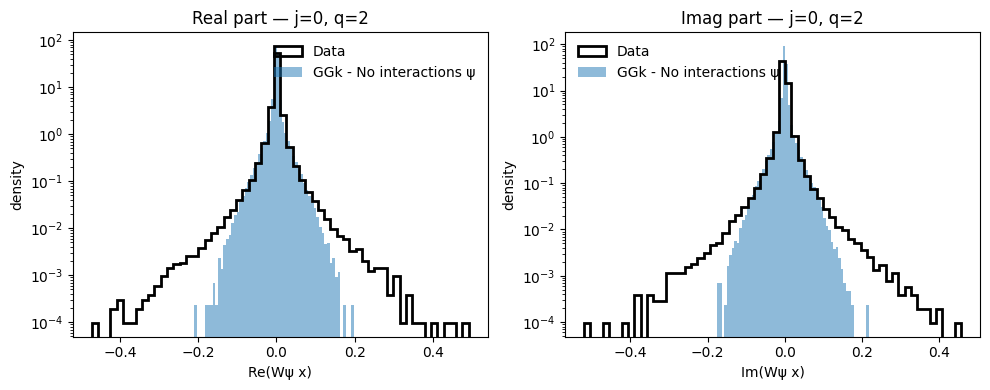

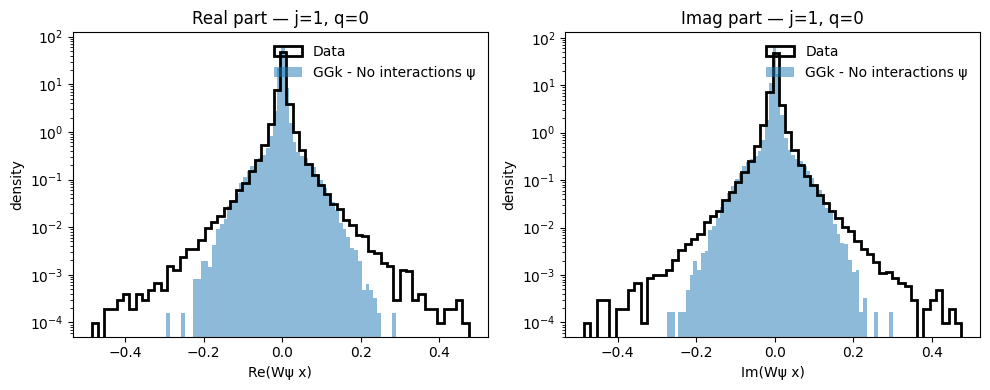

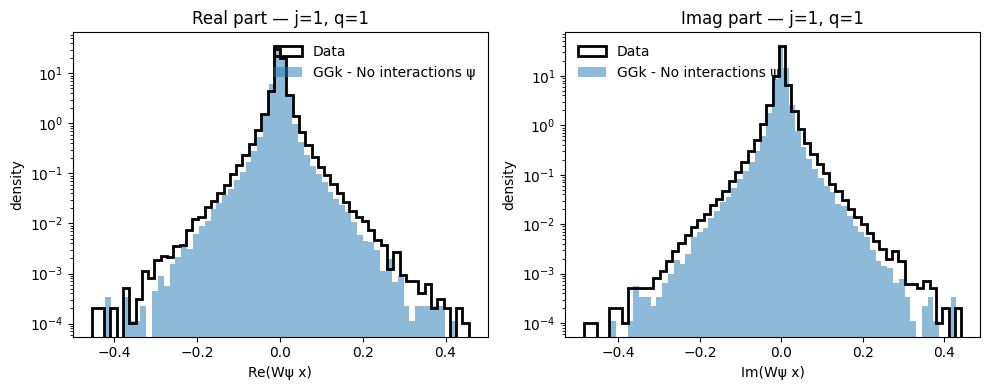

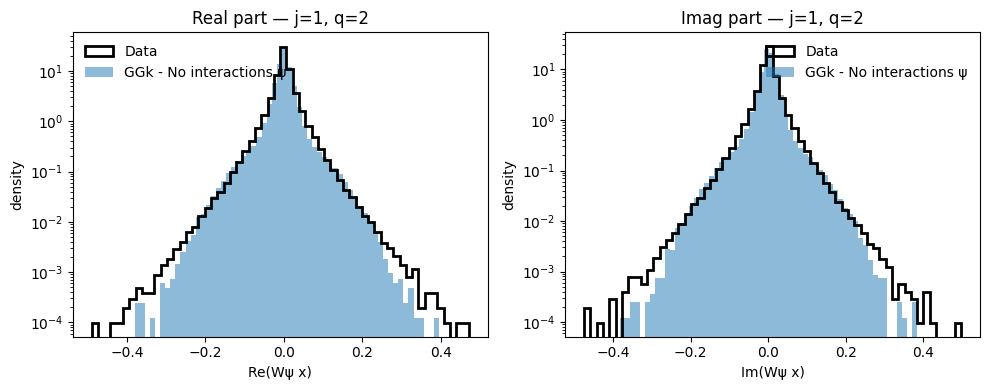

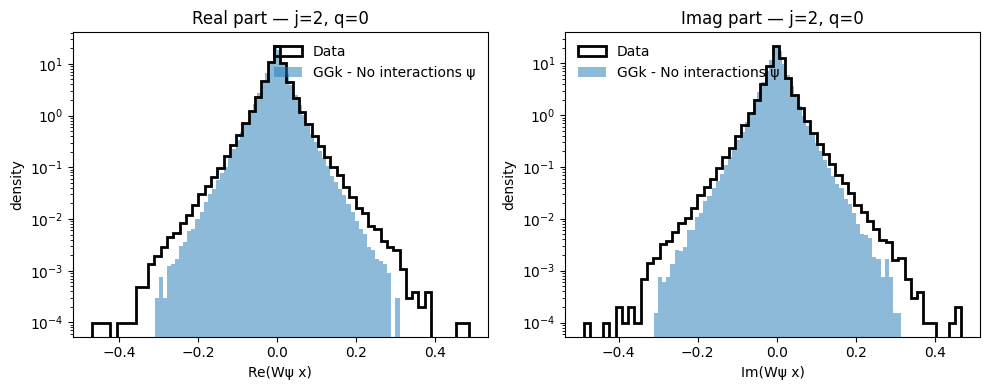

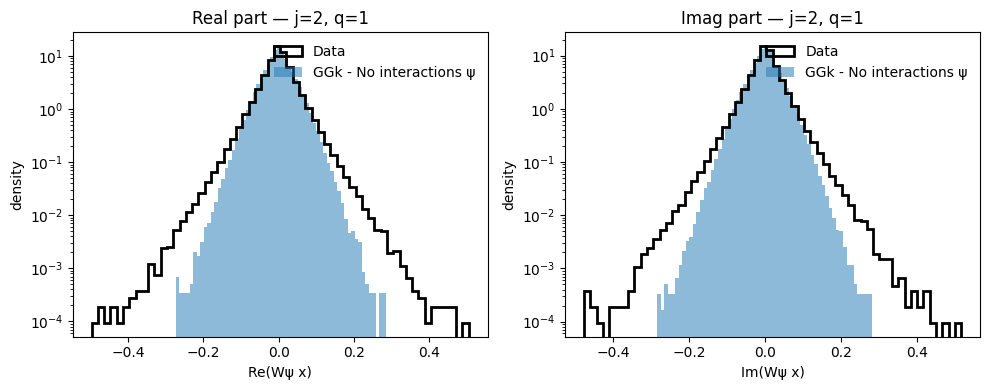

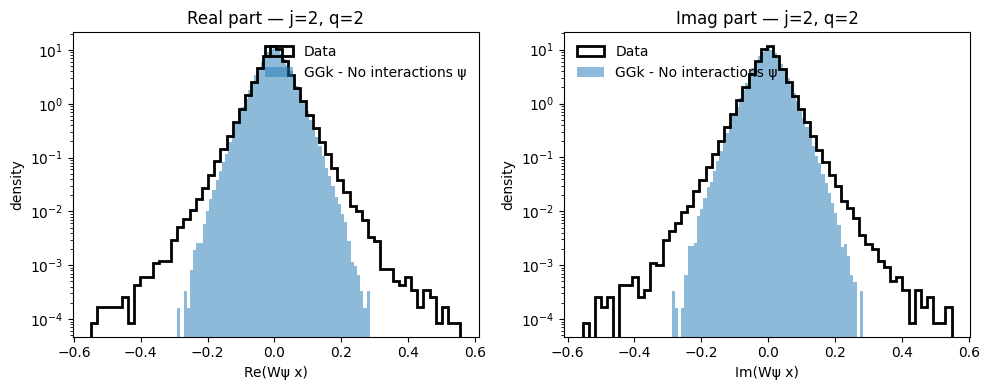

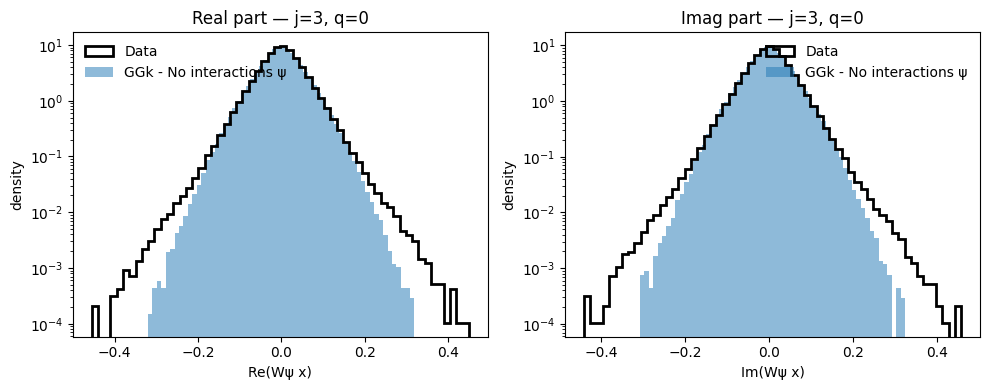

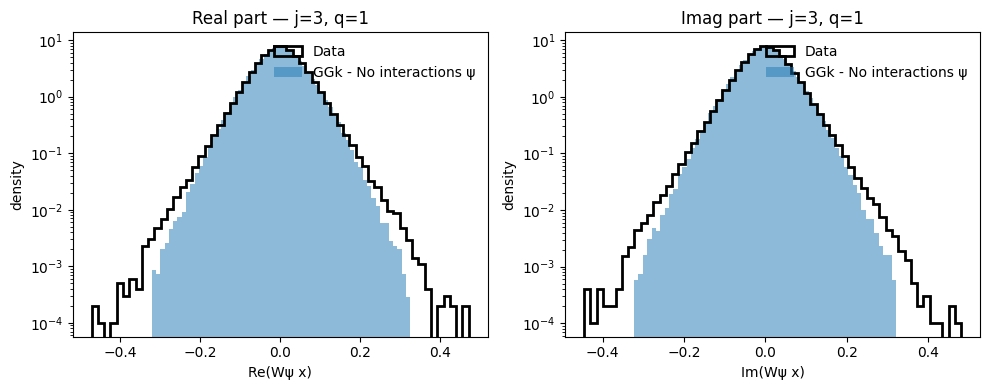

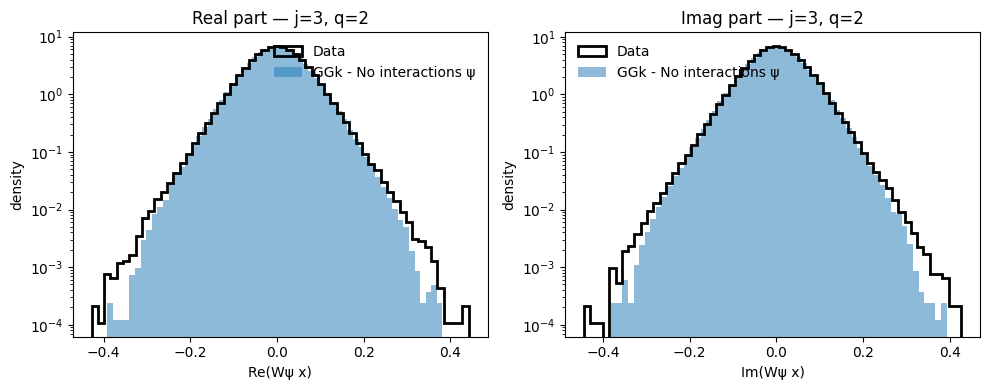

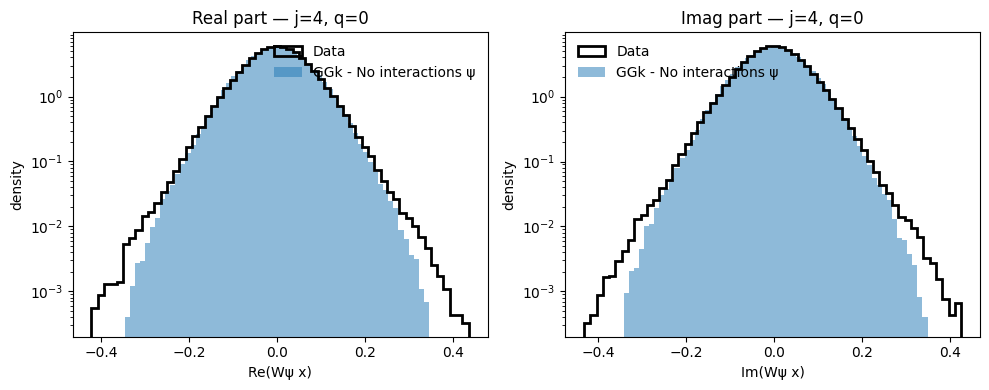

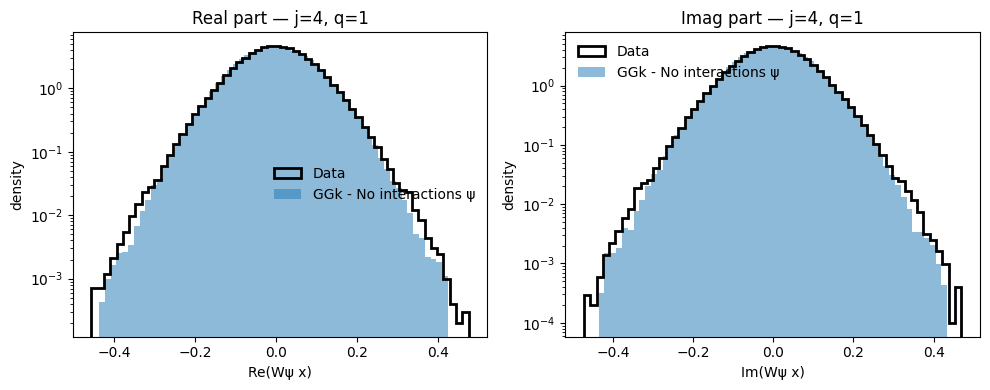

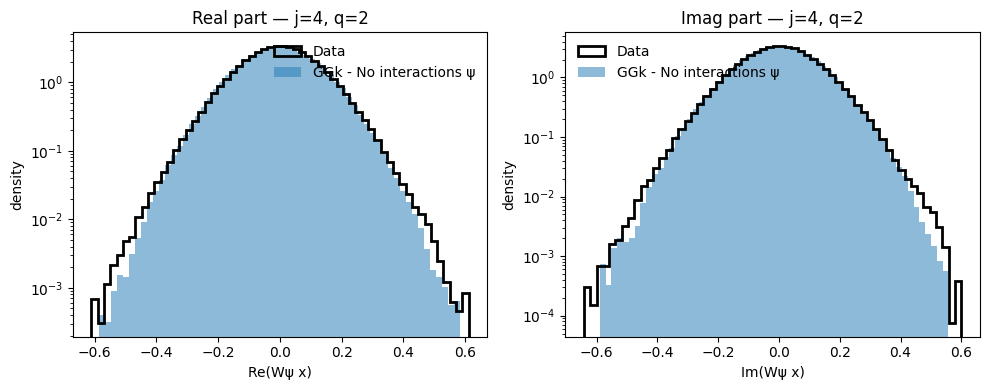

In [12]:
plot_wavelet_real_imag_histograms_overlay(x1, results, experiments) 

In [9]:
oot = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from potentials.potentials_classes.generalized_gauss_Kregions import Scalar_GGD_KRegion

In [10]:
filtersQ = return_Filters(M, J, 3, device=device, include_phi=False)
model = Scalar_GGD_KRegion(filtersQ)
model.fit_reference(x1)

    [model-select] chose K=4  (BIC: K1=-6572770  K2=-6627601  K3=-6633996  K4=-6635922)
[GGD^4][ch 0] Keff=4  cuts=[0.0007 0.0023 0.0149]  pi=[65.5% 19.5% 12.8% 2.3%]  alpha=[1.20 0.36 0.37 0.40]  active=4
    [model-select] chose K=4  (BIC: K1=-6264594  K2=-6288298  K3=-6293111  K4=-6294469)
[GGD^4][ch 1] Keff=4  cuts=[0.0004 0.0014 0.0181]  pi=[45.2% 26.7% 25.8% 2.3%]  alpha=[1.29 0.32 0.35 0.41]  active=4
    [model-select] chose K=4  (BIC: K1=-5299317  K2=-5305712  K3=-5307699  K4=-5307883)
[GGD^4][ch 2] Keff=4  cuts=[0.0002 0.0021 0.0164]  pi=[18.1% 45.1% 30.8% 5.9%]  alpha=[1.52 0.28 0.35 0.40]  active=4
    [model-select] chose K=3  (BIC: K1=-4421117  K2=-4423450  K3=-4423794  K4=-4423754)
[GGD^4][ch 3] Keff=3  cuts=[0.0000 0.0001 0.0515]  pi=[0.0% 4.8% 92.9% 2.3%]  alpha=[1.00 8.00 0.36 0.55]  active=3
    [model-select] chose K=4  (BIC: K1=-3702568  K2=-3704134  K3=-3704058  K4=-3704148)
[GGD^4][ch 4] Keff=4  cuts=[0.0002 0.0116 0.0196]  pi=[4.9% 67.2% 11.1% 16.7%]  alpha=[1.1

/tmp/xpython_4051734/3620469554.py:102: RuntimeWarning: overflow encountered in cast
  logpdf = (np.log(a) - np.log(2.0) - np.log(s) - gammaln(1.0 / a) - (ah / s) ** a)


    [model-select] chose K=3  (BIC: K1=1523328  K2=1516574  K3=1515528  K4=1515839)
[GGD^4][ch 21] Keff=3  cuts=[0.0000 0.7408 1.3568]  pi=[0.0% 66.5% 22.8% 10.6%]  alpha=[1.00 1.95 2.70 2.98]  active=3
[active] 62 active statistics (26 dead slots dropped before they can singularize the Gram)
[prune] dropped 7 near-collinear statistic(s); 55 remain


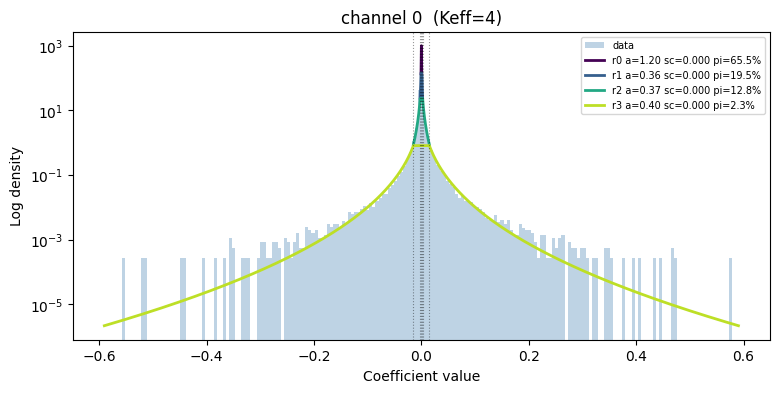

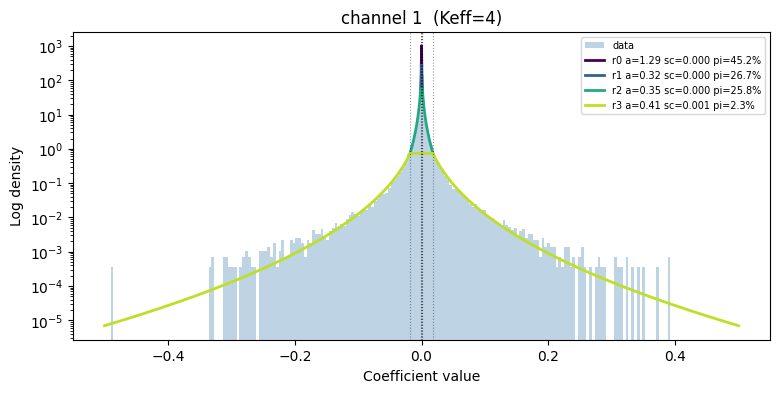

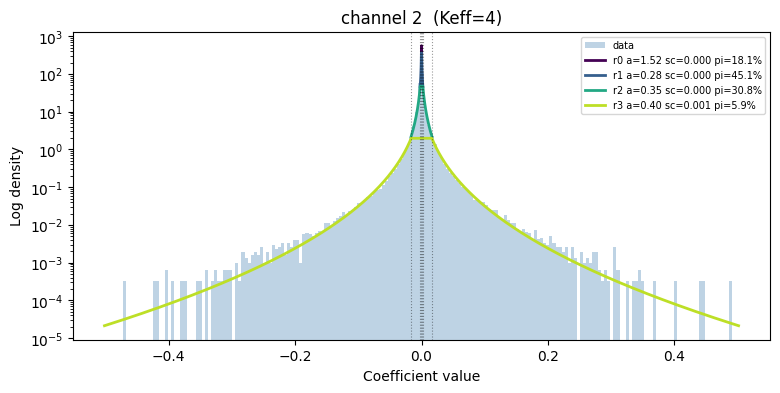

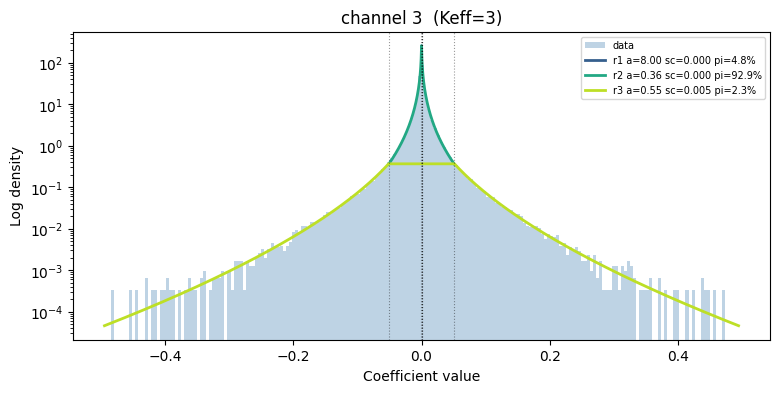

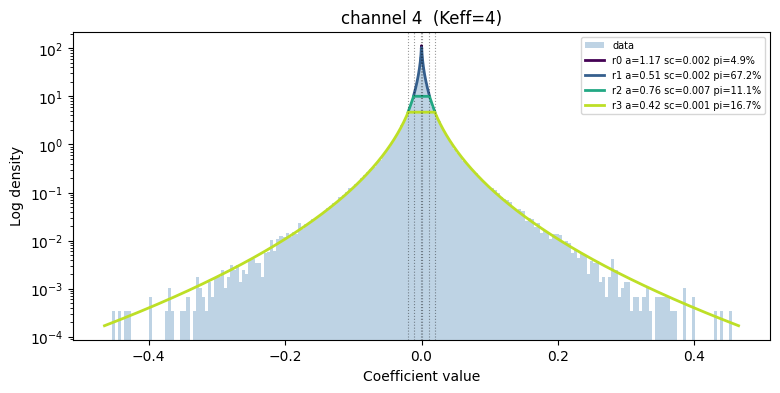

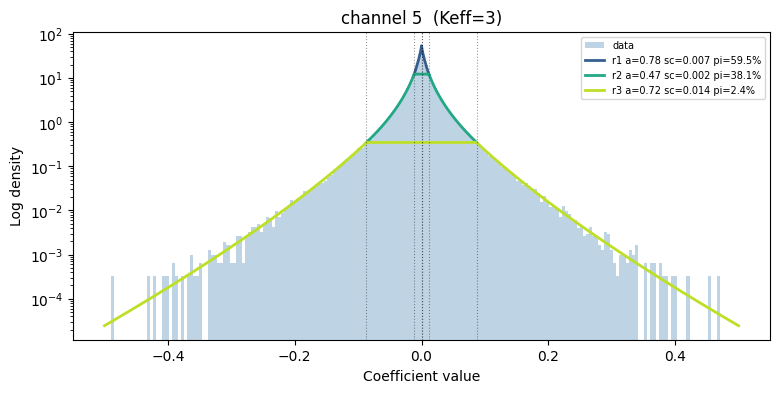

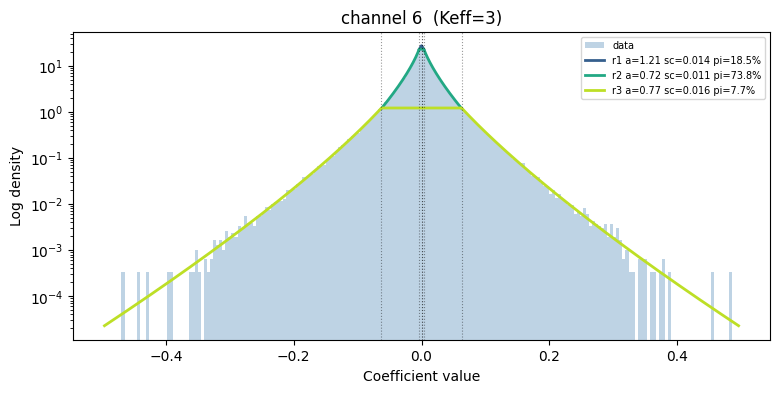

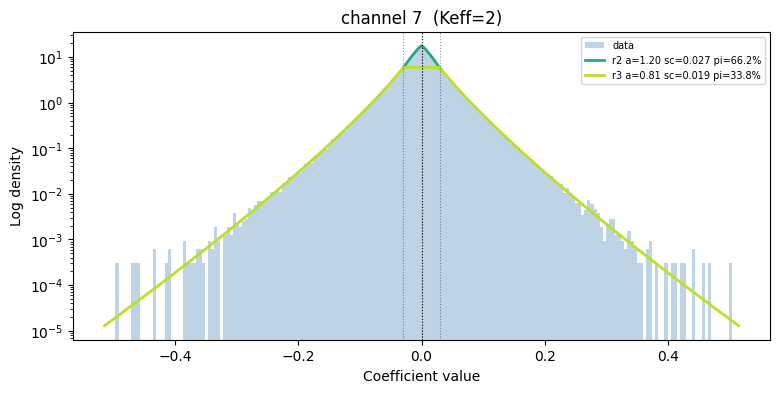

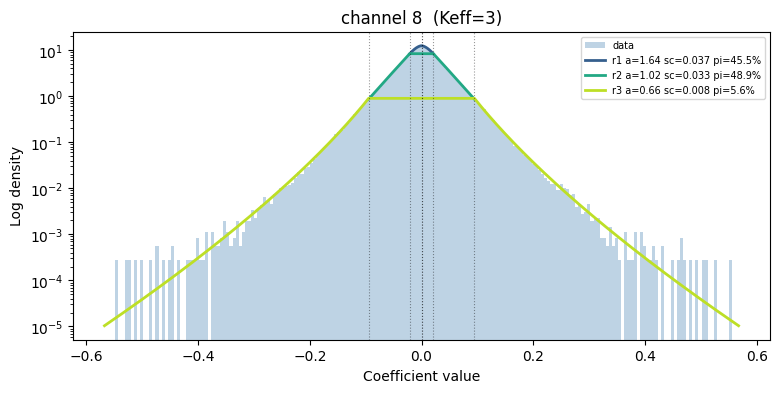

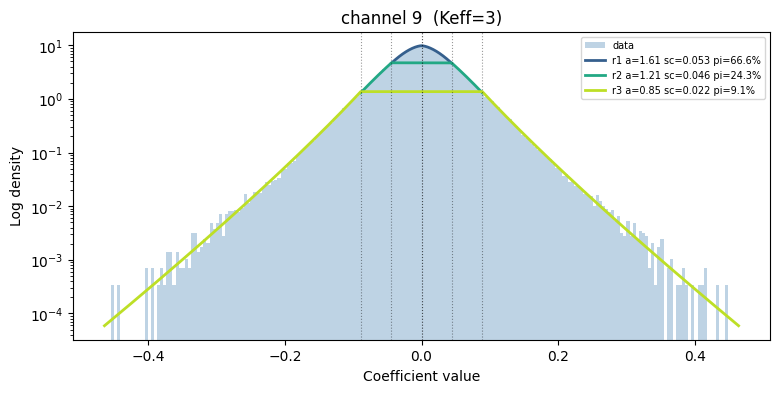

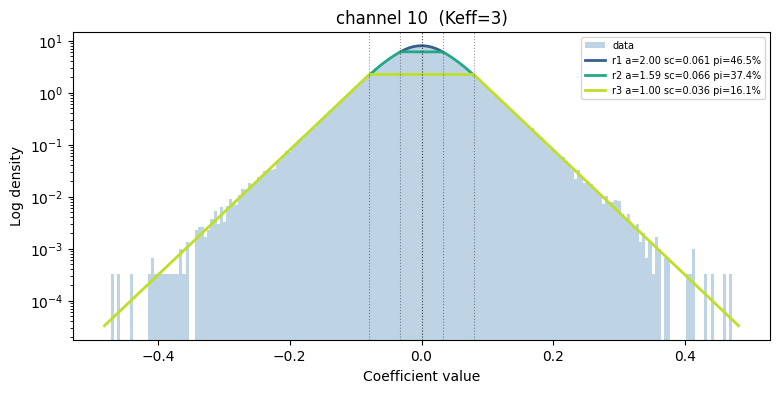

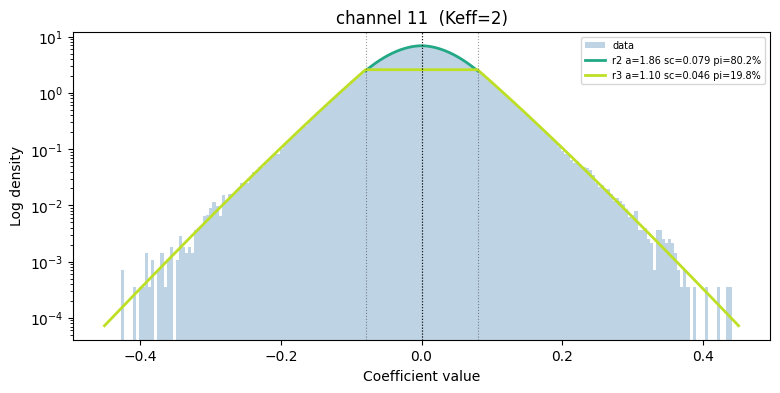

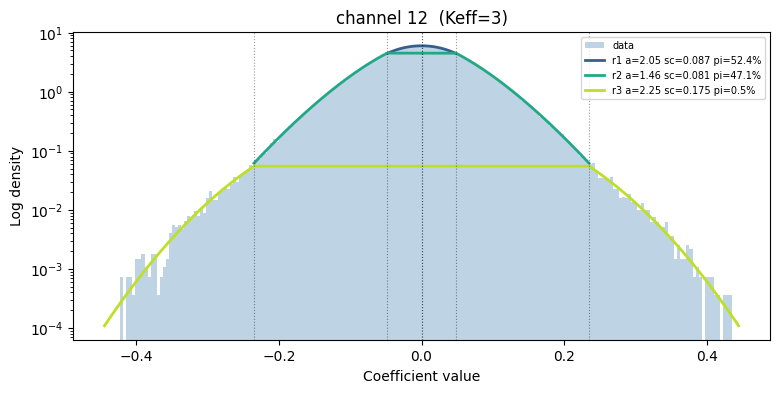

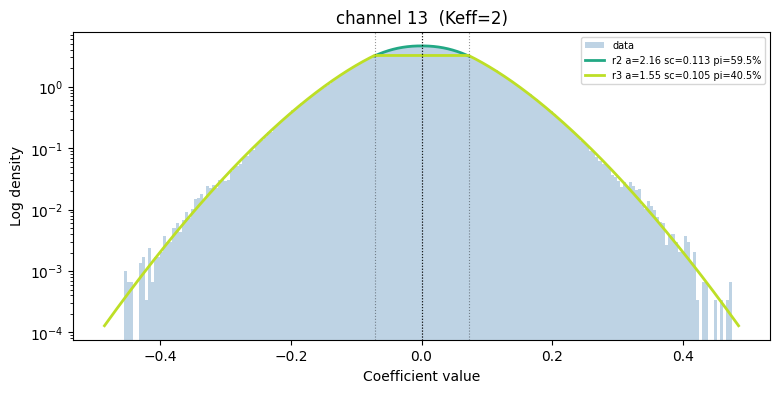

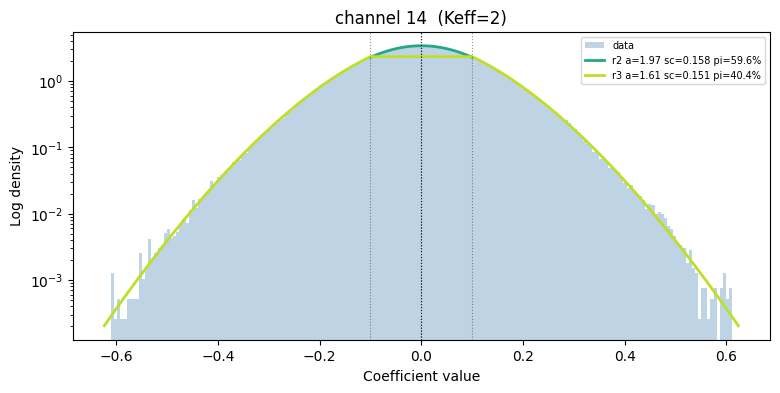

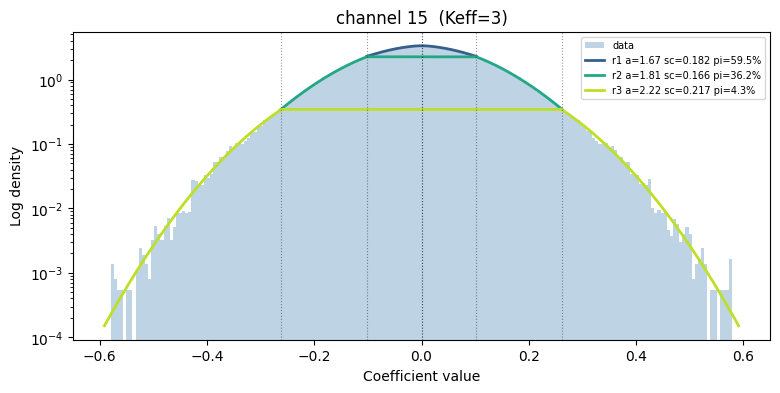

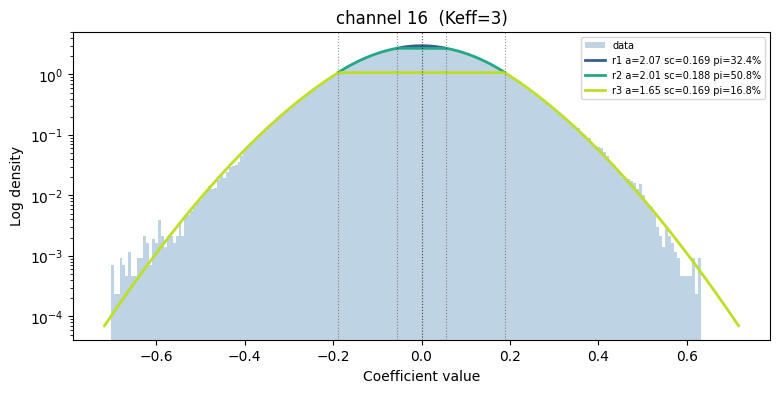

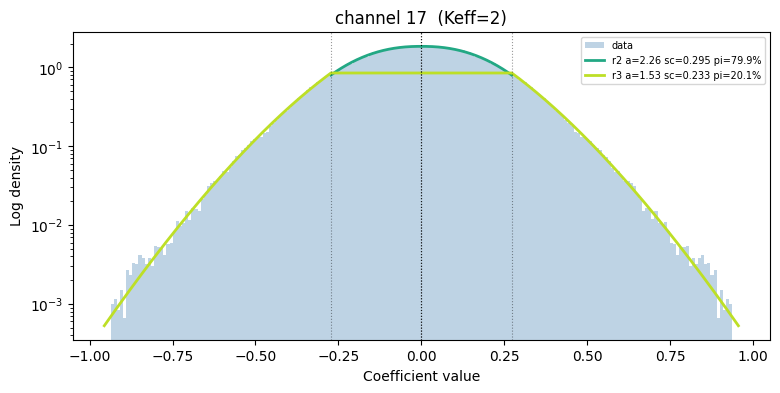

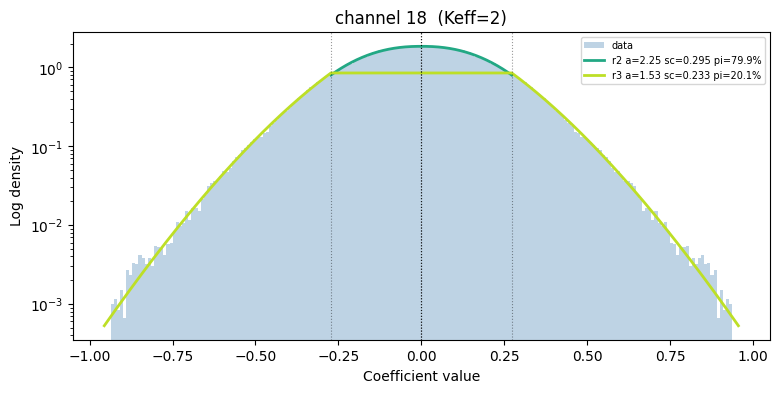

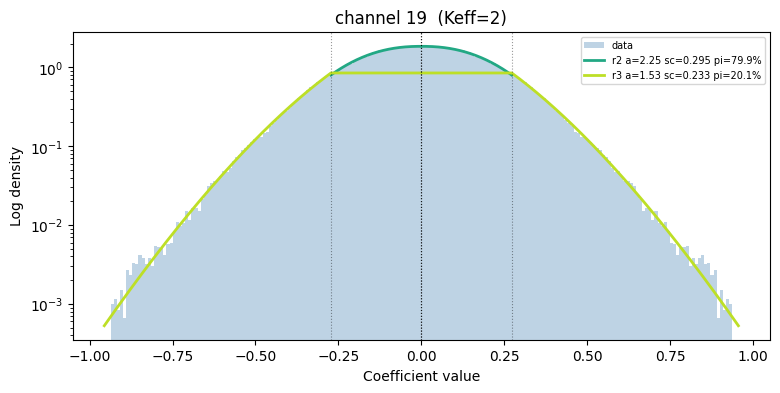

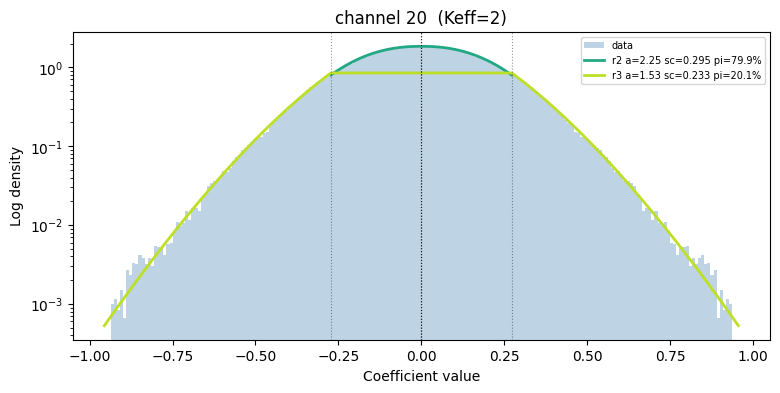

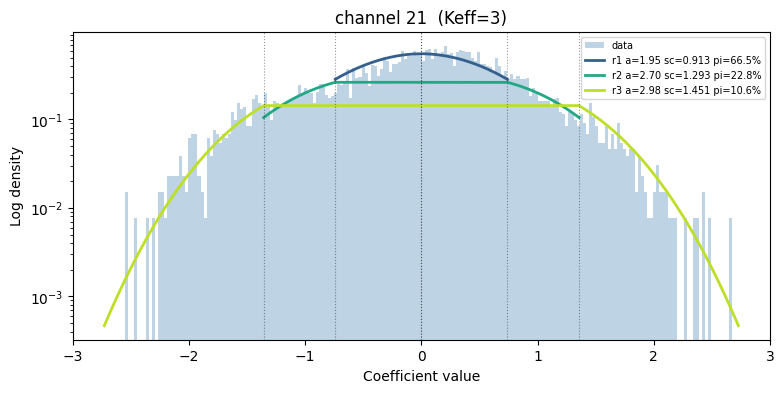

In [11]:
%matplotlib inline 
model.plot_fit(x1)